In [1]:
import matplotlib.pyplot as plt
import numpy as np
from nskernel import NonStationaryKernel
from scipy.optimize import fmin_l_bfgs_b, curve_fit
from spleaf import cov, term
import scipy.io as sp
import emcee


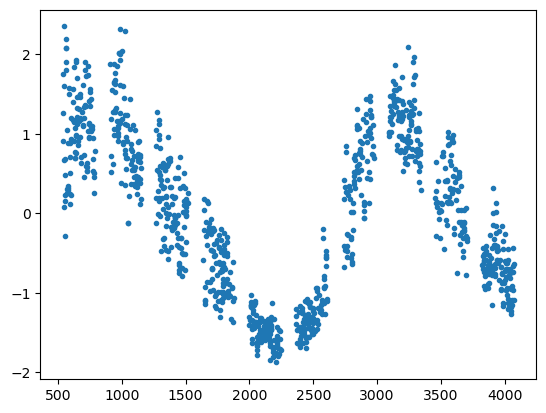

In [2]:
realis = 2
use_file = f"serie_res_bt_G2_1000_4m_NOISE0.09_OGS_MAG_M1_real{realis}.sav"
data = sp.readsav(use_file)

arr_len = len(data['tt'])
tt = data['tt']
rv = data['rv']
rhk = data['ca']
erv = np.zeros(len(rhk))+0.09
rhk_err = np.zeros(len(rhk))+5e-4

rv_mean = np.mean(rv)
rv_std  = np.std(rv)
rv_norm = (rv - rv_mean) / rv_std

# RHK normalization
rhk_mean = np.mean(rhk)
rhk_std  = np.std(rhk)
rhk_norm = (rhk - rhk_mean) / rhk_std

# ERROR normalization using SAME scaling as parent data
erv_norm     = erv / rv_std
rhk_err_norm = rhk_err / rhk_std

# erv_norm *=50
# rhk_err_norm *=50

T = [tt,tt]
Y = [rv_norm,rhk_norm]
Yerr = [erv_norm,rhk_err_norm]

t_full, y_full, yerr_full, series_index = cov.merge_series(T,Y,Yerr)

plt.plot(tt, rv_norm, ".")

In [3]:

def alpha(t, pcyc, phi, k, c):
    # constraint |k| <= 1/3
    # k = (1.0 / 3.0) * np.tanh(k_raw)
    x = (2.0 * np.pi / pcyc) * t + phi

    fc = np.sin(x + k * np.sin(x))  # in [-1, 1]

    # linear normalization to [C, 1]
    return ((1.0 - c) / 2.0) * (fc + 1.0) + c


# def alpha_grad(t, a1, a2, c, pcyc):
#     k = 2.0 * np.pi / pcyc
#     s1 = np.sin(k * t)
#     c1 = np.cos(k * t)

#     fc = a1*s1 + a2*c1 + c

#     R1 = np.sqrt(a1*a1 + a2*a2)
#     Amax = R1 
#     eps = 1e-8
#     D = 2.0 * Amax + eps   # denominator

#     dfc = {
#         'a1': s1,
#         'a2': c1,
#         'c' : 1.0,
#     }

#     dR1 = {'a1': (a1 / (R1 + 1e-12)), 'a2': (a2 / (R1 + 1e-12)),'c':0}
#     dA = {
#         'a1': dR1['a1'],
#         'a2': dR1['a2'],
#         'c' : dR1['c']

#     }

#     numer = fc + Amax

#     grads = {}
#     for pname in ('a1','a2','c'):
#         df = dfc[pname]                # ∂fc/∂p
#         dA_dp = dA[pname]              # ∂Amax/∂p (scalar)
  
#         dD_dp = 2.0 * dA_dp

#         # d(alpha) = ( (df + dA_dp) * D - numer * dD_dp ) / D^2
#         grads[pname] = ((df + dA_dp) * D - numer * dD_dp) / (D*D)

#     dk_dp = -2.0 * np.pi / (pcyc**2)
#     df_dpcyc = a1 * (t * np.cos(k*t)) * dk_dp + \
#                a2 * (-t * np.sin(k*t)) * dk_dp
#     # similarly dA/dpcyc = 0 because Amax doesn't depend on pcyc
#     grads['pcyc'] = (df_dpcyc * D - numer * 0.0) / (D*D)

#     return grads


def alpha_grad(t, pcyc, phi, k, c):
    
    omega = 2.0 * np.pi / pcyc
    x = omega * t + phi

    # k is provided directly (assumed already constrained to |k| <= 1/3)
    # (previously: k = (1.0 / 3.0) * np.tanh(k_raw))

    inner = x + k * np.sin(x)
    s_inner = np.sin(inner)
    c_inner = np.cos(inner)

    scale = (1.0 - c) / 2.0

    # d(inner)/dx
    d_inner_dx = 1.0 + k * np.cos(x)

    # d alpha / d s
    d_alpha_ds = scale

    # chain: d alpha / d inner
    d_alpha_dinner = d_alpha_ds * c_inner

    grads = {}

    # ----- derivative wrt phi -----
    # dx/dphi = 1
    grads['phi'] = d_alpha_dinner * d_inner_dx

    # ----- derivative wrt pcyc -----
    # omega = 2π/pcyc
    domega_dp = -2.0 * np.pi / (pcyc ** 2)
    dx_dp = domega_dp * t
    grads['pcyc'] = d_alpha_dinner * d_inner_dx * dx_dp

    # ----- derivative wrt k -----
    # k is the input directly, so dk/dk = 1
    d_inner_dk = np.sin(x)
    grads['k'] = d_alpha_dinner * d_inner_dk

    # ----- derivative wrt c -----
    # alpha = scale*(s+1) + c
    # scale = (1-C)/2
    # d alpha / dC = -(1/2)*(s+1) + 1
    grads['c'] = -0.5 * (s_inner + 1.0) + 1.0

    return grads


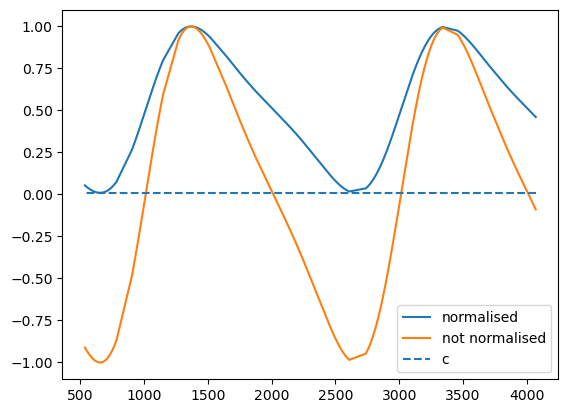

In [4]:
k = 0.5
plt.plot(t_full, alpha(t_full, 2000, 3.1, k,0.01),label="normalised")
plt.plot(t_full, np.sin((2.0 * np.pi / 2000) * t_full + 3.1 +  k * np.sin((2.0 * np.pi / 2000) * t_full + 3.1)),label="not normalised")
plt.hlines(0.01,np.max(t_full),np.min(t_full),linestyle="dashed",label="c")
plt.legend()

(550.0, 800.0)

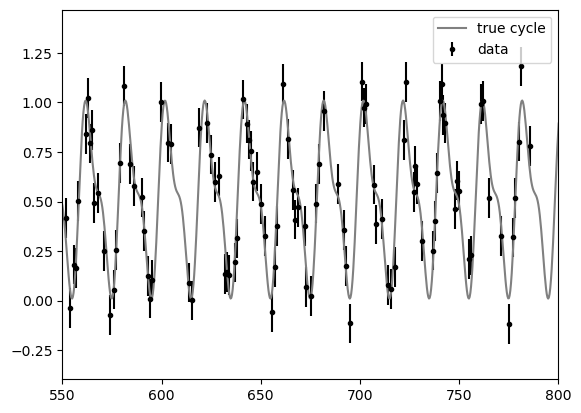

In [5]:
a = 0.7
b = 0.5
c = 0.3
d = 1.1
e = 0.2
p = 20

def fake_cycle_func(t):
    fc = a*np.sin(2*np.pi*t/p + b) + c*np.sin(4*np.pi*t/p + d) + e
    return (fc-np.min(fc))/(np.max(fc)-np.min(fc)) + 0.01

fake_cycle = fake_cycle_func(t_full[series_index[0]])
noise = 0.1 * np.random.randn(len(fake_cycle))
fake_cycle += noise

plt.figure()
plt.errorbar(t_full[series_index[0]], fake_cycle, yerr=0.1, fmt=".", color="black",label="data")
plt.plot(np.linspace(np.min(t_full), np.max(t_full), 10000), fake_cycle_func(np.linspace(np.min(t_full), np.max(t_full), 10000)), color="gray",label="true cycle")
plt.legend()
plt.xlim(550, 800)

(550.0, 800.0)

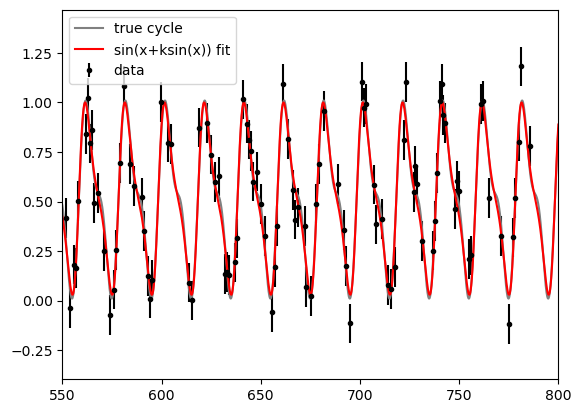

In [6]:
xbest, covar = curve_fit(alpha, t_full[series_index[0]], fake_cycle, p0=[20, 0.0, -1.5, 0.01],sigma = 0.1,check_finite=False)
plt.figure()
plt.errorbar(t_full[series_index[0]], fake_cycle, yerr=0.1, fmt=".", color="black",label="data")
plt.plot(np.linspace(np.min(t_full), np.max(t_full), 100000), fake_cycle_func(np.linspace(np.min(t_full), np.max(t_full), 100000)), color="gray",label="true cycle")
plt.plot(np.linspace(np.min(t_full), np.max(t_full), 100000), alpha(np.linspace(np.min(t_full), np.max(t_full), 100000), *xbest), color="red",label="sin(x+ksin(x)) fit")
plt.legend()
plt.xlim(550, 800)

array([ 2.31077734e+03, -1.01473016e+00,  4.06739498e-01, -1.59518038e+00])

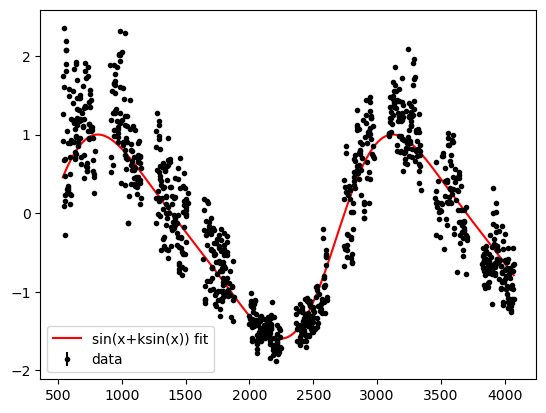

In [7]:
xbest, covar = curve_fit(alpha, t_full[series_index[0]], y_full[series_index[0]], p0=[2500, 0.0, 0.2, 0.01],sigma = 2.0,check_finite=False)
plt.figure()
plt.errorbar(t_full[series_index[0]], y_full[series_index[0]], yerr=yerr_full[series_index[0]], fmt=".", color="black",label="data")
# plt.plot(np.linspace(np.min(t_full), np.max(t_full), 100000), fake_cycle_func(np.linspace(np.min(t_full), np.max(t_full), 100000)), color="gray",label="true cycle")
plt.plot(np.linspace(np.min(t_full), np.max(t_full), 1000), alpha(np.linspace(np.min(t_full), np.max(t_full), 1000), *xbest), color="red",label="sin(x+ksin(x)) fit")
plt.legend()
# plt.xlim(550, 800)
xbest

In [5]:
class MultiSeriesKernel(term.MultiSeriesKernel):
  def _grad_param(self, grad_dU=None, grad_dV=None):
    if grad_dU is not None or grad_dV is not None:
      raise NotImplementedError()
    return super()._grad_param()

In [9]:
stds = [np.std(y) for y in Y]
sig = np.var(y_full)   
prot = 20.0
Q = 1.0

rvjit = 0.1*stds[0]
rhkjit = 0.1*stds[1]

# a1, a2, c, pcyc = 0.5, -6.1, 2.0, 2500.0

pcyc, phi, k, c = 2500.0, np.pi/10, 0.2, 0.01

rho = 4.5
eta = 1.6

C = cov.Cov(
  t_full,
  err=term.Error(yerr_full),
  rv_jit=term.InstrumentJitter(series_index[0], rvjit),
  rhk_jit=term.InstrumentJitter(series_index[1], rhkjit),
  gp=term.SimpleProductKernel(
      nonstat=NonStationaryKernel(alpha, alpha_grad, pcyc=pcyc, phi = phi, k = k, c = c),
      rot = MultiSeriesKernel(term.ESPKernel(sig,prot,rho,eta), series_index, 
        np.ones(2) * stds, 
        np.array([stds[0], 0.0])
    ),
  )
)
          




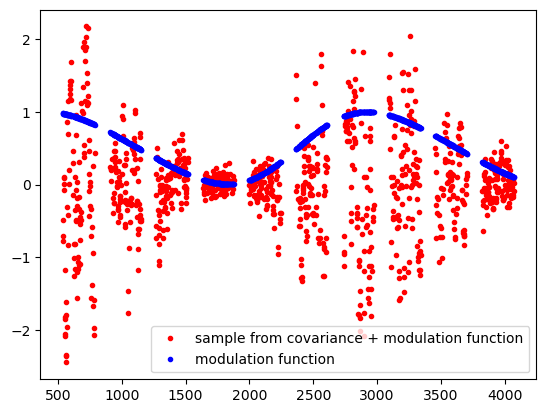

In [10]:
fc_norm = alpha(t_full[series_index[0]], pcyc, phi, k, c)
drawn_sample = C.sample()[series_index[0]]

plt.plot(t_full[series_index[0]], drawn_sample, ".", color="red", label="sample from covariance + modulation function")
plt.plot(t_full[series_index[0]], fc_norm, ".", color="blue", label="modulation function")
plt.legend()

In [12]:
rvjit_max = 5*stds[0]
rhkjit_max = 5*stds[1]

prot_min = 17.0
prot_max = 30.0
Q_min = 0.7
Q_max = 1.7

pcyc_min = 2000.0
pcyc_max = 3000.0


eta_min = 0.4
eta_max = 2.9
rho_min = 2.8
rho_max = 6.2

alpha_0_max = 5*stds[0]
alpha_1_max = 5*stds[1]
beta_0_max  = 5*stds[0]
beta_1_max  = 5*stds[1]
gamma_0_max = 5*stds[0]
gamma_1_max = 5*stds[1]
bounds_list = [
    (0.0, rvjit_max),                     # rv_jit.sig
    (0.0, rhkjit_max),                     # rhk_jit.sig
    (pcyc_min, pcyc_max),  
    (0,np.pi*2), # phi
    (-0.4,0.4),
    (0.1,0.9),
    # (-10,10),
    
    (prot_min, prot_max),                 # rot.P0 (period)
    # (Q_min, Q_max),                      # rot.Q (quality factor)
    (rho_min, rho_max),                   # rot.rho 
    (eta_min, eta_max),                   # rot.eta
    (0, alpha_0_max),         # rot.alpha_0 (set lower bound to zero)
    (-alpha_1_max, alpha_1_max),         # rot.alpha_1
    (-beta_0_max, beta_0_max),         # rot.beta_0      
    (0.6, gamma_0_max*2+2),         # rot.gamma_0
    (0.6, gamma_1_max*2+2),         # rot.gamma_1
    (-gamma_0_max, gamma_0_max),         # delta_0 (offset for series 0)
    (-gamma_1_max, gamma_1_max),         # delta_1 (offset for series 1)
]

C.param

['rv_jit.sig',
 'rhk_jit.sig',
 'gp.nonstat_pcyc',
 'gp.nonstat_phi',
 'gp.nonstat_k',
 'gp.nonstat_c',
 'gp.rot_sig',
 'gp.rot_P',
 'gp.rot_rho',
 'gp.rot_eta',
 'gp.rot_alpha_0',
 'gp.rot_alpha_1',
 'gp.rot_beta_0',
 'gp.rot_beta_1']

In [13]:
fitted = [k for k, key in enumerate(C.param) if key != 'gp.rot_sig' and key != "gp.rot_beta_1"]  
params = [C.param[k] for k in fitted]
x0 = C.get_param(params)

x0 = np.append(x0,[0.0,0.0,0.0,0.0])

def negloglike(x, y, C):
  
  C.set_param(x[:len(params)], params)
  fc = alpha(t_full, x[2],x[3],x[4],x[5])
  fc_unnorm = (fc - x[5]) / ((1.0 - x[5]) / 2.0) - 1
  y_model = y.copy()
  y_model[series_index[0]] -= (x[-4]*fc_unnorm[series_index[0]] + x[-2])
  y_model[series_index[1]] -= (x[-3]*fc_unnorm[series_index[1]] + x[-1])
  nll = -C.loglike(y_model)
  # gradient
  lg = C.loglike_grad()
  dL_dy = np.asarray(lg[0]).reshape(-1)      # shape (N_total,) 
  dL_dparams = np.asarray(lg[1]).reshape(-1) # shape (12,)      

  base_grad = - dL_dparams[fitted]  

  # gradients wrt gamma (scale of fc)
  grad_gamma_0 = np.sum(dL_dy[series_index[0]] * fc_unnorm[series_index[0]])
  grad_gamma_1 = np.sum(dL_dy[series_index[1]] * fc_unnorm[series_index[1]])
  # gradients wrt delta (additive offsets)
  grad_delta_0 = np.sum(dL_dy[series_index[0]])
  grad_delta_1 = np.sum(dL_dy[series_index[1]])

  nll_grad = np.concatenate([np.asarray(base_grad).ravel(), np.array([grad_gamma_0, grad_gamma_1, grad_delta_0, grad_delta_1])])


  # nll_grad = -C.loglike_grad()[1][fitted]

  return (nll, nll_grad)


result = fmin_l_bfgs_b(negloglike, x0, args=(y_full, C), bounds=bounds_list)
xbest = result[0]

C.set_param(xbest[:len(params)], params)
C.set_param([0.0], ['gp.rot_beta_1'])


print(params)
print(xbest)

['rv_jit.sig', 'rhk_jit.sig', 'gp.nonstat_pcyc', 'gp.nonstat_phi', 'gp.nonstat_k', 'gp.nonstat_c', 'gp.rot_P', 'gp.rot_rho', 'gp.rot_eta', 'gp.rot_alpha_0', 'gp.rot_alpha_1', 'gp.rot_beta_0']
[ 2.35184709e-01  7.37147747e-02  2.49996980e+03  1.30762908e+00
  1.58923045e-01  7.72830943e-01  2.00238561e+01  5.29135944e+00
  1.98542992e+00  9.87497085e-01  9.87315873e-01  4.29381691e-01
  8.60119653e-01  6.55800830e-01 -3.91942922e-02 -7.54108477e-02]


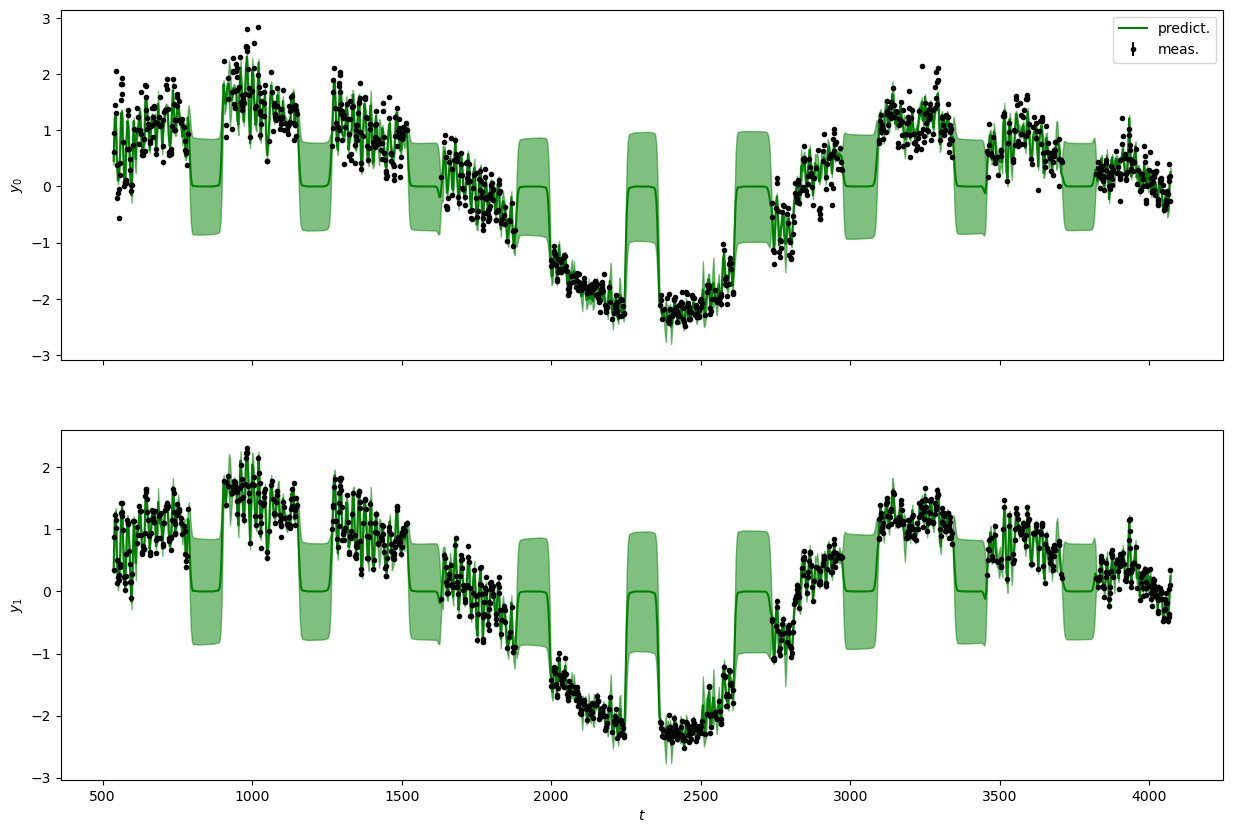

In [14]:
# C.set_param([0.0], ['gp.beta_0'])  
# C.set_param(xbest)

# C.set_param(samples[-1,0,:], params)

tsmooth = np.linspace(np.min(t_full), np.max(t_full), 1000)
_, axs = plt.subplots(2, 1, sharex=True, figsize=(15, 10))


for k in range(2):
  # Predict time series k
  C.kernel['gp'].set_conditional_coef(series_id=k)
  # C.kernel['rot'].set_conditional_coef(series_id=k)
  fc = alpha(t_full, xbest[2],xbest[3],xbest[4],xbest[5])
  fc_unnorm = (fc - xbest[5]) / ((1.0 - xbest[5]) / 2.0) - 1
  y_model = y_full.copy()
  y_model[series_index[0]] -= (xbest[-4]*fc_unnorm[series_index[0]] + xbest[-2])
  y_model[series_index[1]] -= (xbest[-3]*fc_unnorm[series_index[1]] + xbest[-1])

  mu, var = C.conditional(y_model, tsmooth, calc_cov='diag')
  mu_res, _ = C.conditional(y_model, T[k], calc_cov='diag')
  if k == 0:
    res_rv = Y[k] - mu_res
  else:
    res_rhk = Y[k] - mu_res
  # Plot
  
  ax = axs[k]
  if k ==0 :
    ax.errorbar(T[k], Y[k]-(xbest[-4]*fc_unnorm[series_index[0]]+xbest[-2]), Yerr[k], fmt='.', color='k', label='meas.')
  if k == 1:
    ax.errorbar(T[k], Y[k]-(xbest[-3]*fc_unnorm[series_index[1]]+xbest[-1]), Yerr[k], fmt='.', color='k', label='meas.')
  ax.fill_between(tsmooth,
    mu - np.sqrt(var),
    mu + np.sqrt(var),
    color='g',
    alpha=0.5)
  ax.plot(tsmooth, mu, 'g', label='predict.')
  ax.set_ylabel(f'$y_{k}$')
ax.set_xlabel('$t$')
axs[0].legend()

plt.show()

2499.9698031633143 1.3076290754573272 0.1589230447335921 0.7728309430793132


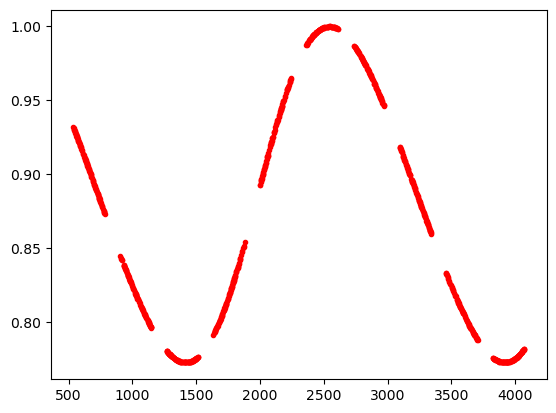

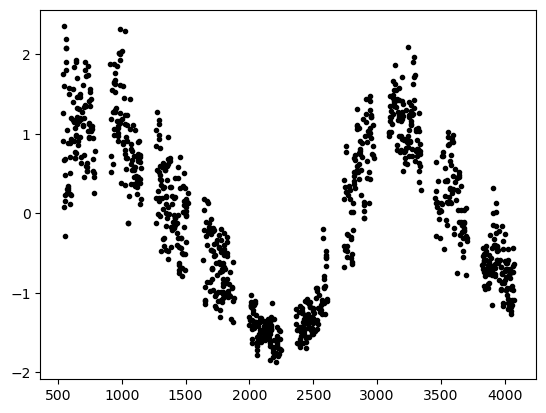

In [15]:
fc = alpha(t_full[series_index[0]], xbest[2],xbest[3],xbest[4],xbest[5])
plt.figure()
plt.plot(t_full[series_index[0]],fc, ".", color="red", label="fitted modulation function")
plt.figure()
plt.plot(t_full[series_index[0]],y_full[series_index[0]],".",color="black")
print(xbest[2],xbest[3],xbest[4],xbest[5])

In [18]:
def log_prior(theta):
    # unpack theta (added delta_0, delta_1 as final two entries)
    # rv_jit, rhk_jit, pcyc, phi, k_raw, c, rot_P0, rot_Q, rot_alpha_0, rot_alpha_1, rot_beta_0, gamma_0, gamma_1, delta_0, delta_1 = theta
    rv_jit, rhk_jit, pcyc, phi, k, c, rot_P0, rot_rho, rot_eta, rot_alpha_0, rot_alpha_1, rot_beta_0, gamma_0, gamma_1, delta_0, delta_1 = theta
    phi = phi % (2*np.pi)
    if 0.0 < rv_jit < rvjit_max and 0.0 < rhk_jit < rhkjit_max and pcyc_min < pcyc < pcyc_max and 0 < phi < np.pi*2 and -0.4< k < 0.4 and 0.2 < c < 0.8 and prot_min < rot_P0 < prot_max and rho_min < rot_rho < rho_max and eta_min < rot_eta < eta_max and 0.0 < rot_alpha_0 < alpha_0_max and -alpha_1_max < rot_alpha_1 < alpha_1_max and -beta_0_max < rot_beta_0 < beta_0_max and 0.0 < gamma_0 < gamma_0_max and 0.0 < gamma_1 < gamma_0_max and -gamma_0_max < delta_0 < gamma_0_max and -gamma_0_max < delta_1 < gamma_0_max:
        return 0.0
    return -np.inf

def log_probability(theta, y, C):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + -1*negloglike(theta, y, C)[0]

x0 = xbest.copy()
print(x0)
print(log_prior(x0))    

# x0 = [0.03, 0.2, 1500.0, 0.015, 4.0, 4.0, 4.0]
ndim = len(x0)
pos = x0 + 1e-4 * np.random.randn(ndim*3, ndim)
nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(y_full, C)
)
sampler.run_mcmc(pos, 2000, progress=True);



[ 2.35184709e-01  7.37147747e-02  2.49996980e+03  1.30762908e+00
  1.58923045e-01  7.72830943e-01  2.00238561e+01  5.29135944e+00
  1.98542992e+00  9.87497085e-01  9.87315873e-01  4.29381691e-01
  8.60119653e-01  6.55800830e-01 -3.91942922e-02 -7.54108477e-02]
0.0


100%|██████████| 2000/2000 [12:36<00:00,  2.64it/s]


['rv_jit.sig', 'rhk_jit.sig', 'gp.nonstat_pcyc', 'gp.nonstat_phi', 'gp.nonstat_k', 'gp.nonstat_c', 'gp.rot_P', 'gp.rot_rho', 'gp.rot_eta', 'gp.rot_alpha_0', 'gp.rot_alpha_1', 'gp.rot_beta_0', 'gamma_0', 'gamma_1', 'delta_0', 'delta_1']


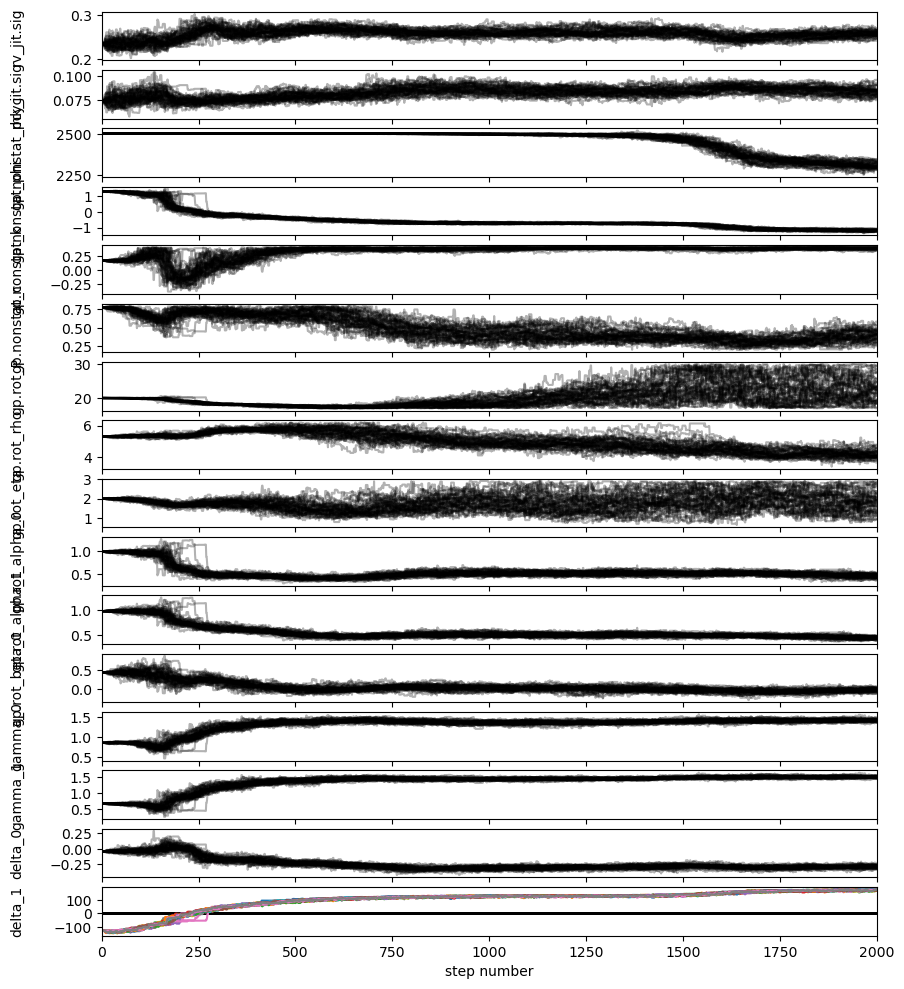

In [19]:
# ig, axes = plt.subplots(13, figsize=(10, 12), sharex=True)
ig, axes = plt.subplots(len(params) + 4, figsize=(10, 12), sharex=True)
samples = sampler.get_chain()

# labels = params + ['gamma_0', 'gamma_1', 'delta_0', 'delta_1']
labels = params + ['gamma_0', 'gamma_1', 'delta_0', 'delta_1']
print(labels)
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

logp = sampler.get_log_prob(flat=False)
axes[-1].plot(logp)

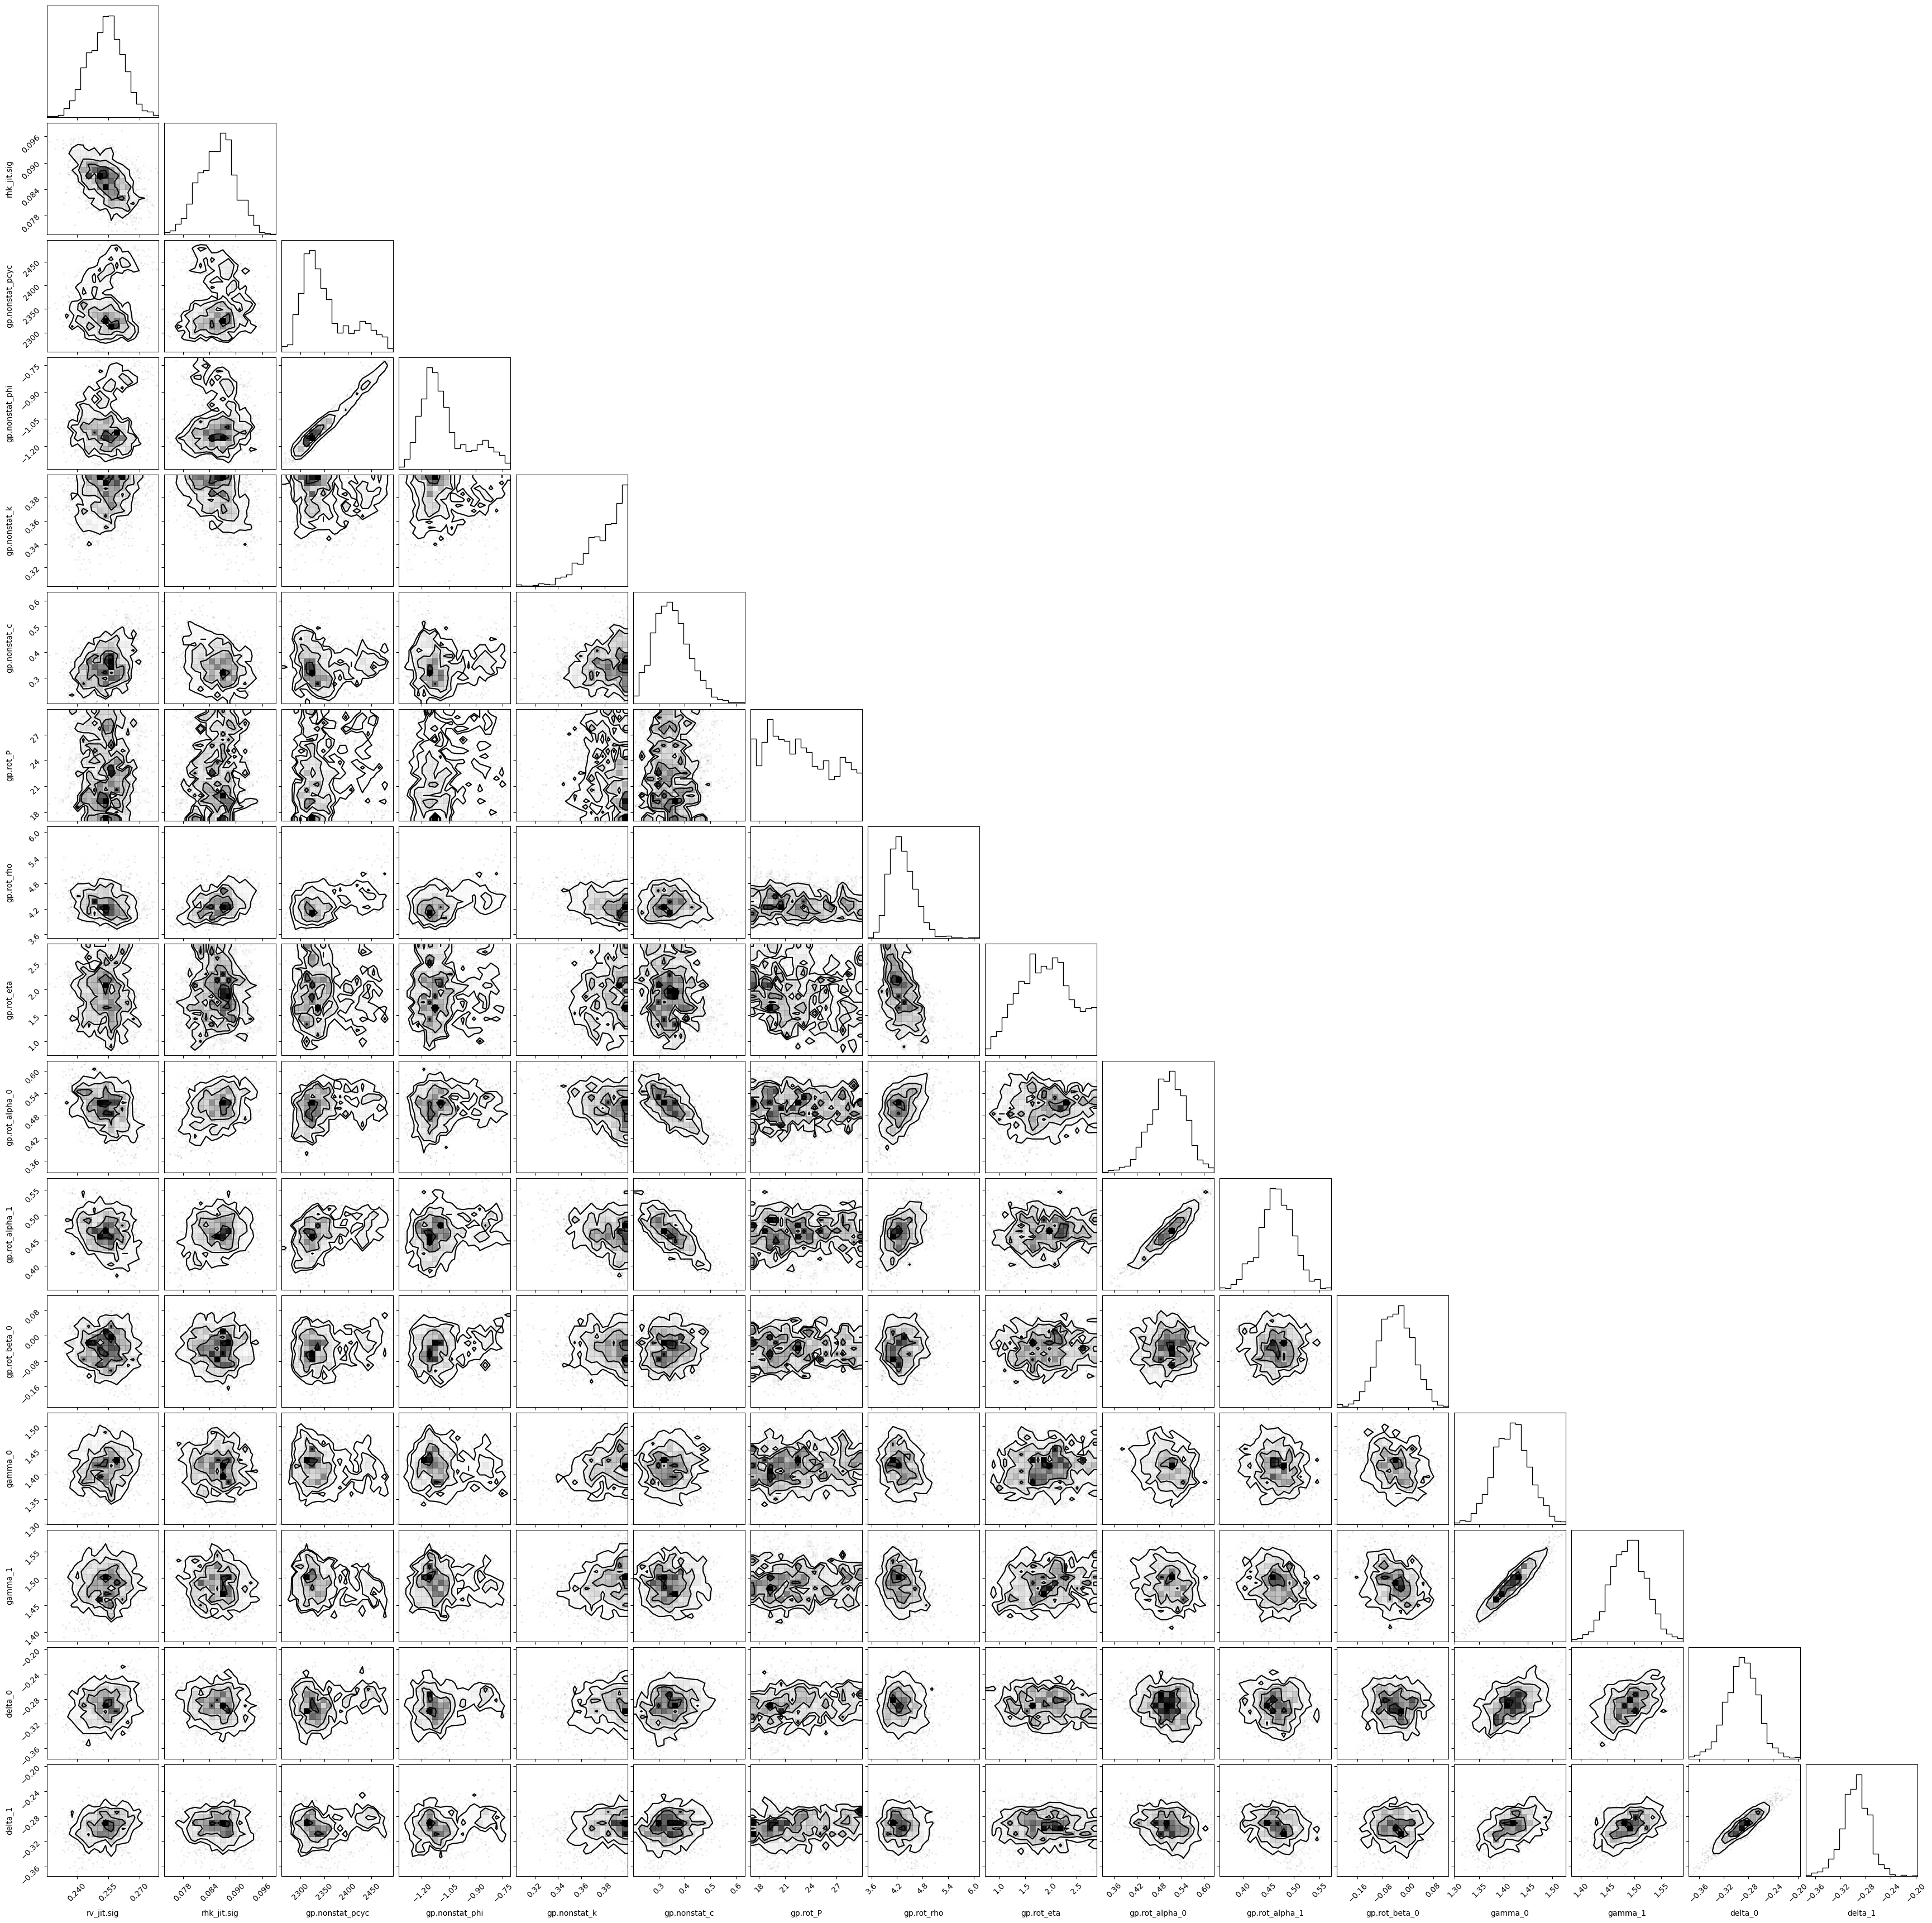

In [20]:
import corner

flat_samples = sampler.get_chain(discard=1500, thin=15, flat=True)

fig = corner.corner(
    flat_samples, labels=labels
);



In [21]:
burn = 1500   
thin = 1

flat_samples = sampler.get_chain(discard=burn, thin=thin, flat=True)   # shape (n_samples, ndim)
flat_logp    = sampler.get_log_prob(discard=burn, thin=thin, flat=True) # shape (n_samples,)

finite_mask = np.isfinite(flat_logp)
flat_samples = flat_samples[finite_mask]
flat_logp    = flat_logp[finite_mask]

map_idx = np.argmax(flat_logp)
map_sample = flat_samples[map_idx]
map_logp = flat_logp[map_idx]

print("MAP index (in flattened, post-burn chain):", map_idx)
print("MAP log-posterior:", map_logp)
print("MAP sample (theta):", map_sample)

# np.save("map_sample.npy", map_sample)

MAP index (in flattened, post-burn chain): 23243
MAP log-posterior: 176.20874971032868
MAP sample (theta): [ 2.56077048e-01  7.82904370e-02  2.29771031e+03 -1.20629058e+00
  3.97696146e-01  3.88201456e-01  1.99941473e+01  3.88119780e+00
  1.90232461e+00  4.34931314e-01  4.20223863e-01 -6.68877194e-04
  1.43327702e+00  1.51236798e+00 -2.60088504e-01 -2.70729128e-01]


In [22]:
print(params)

['rv_jit.sig', 'rhk_jit.sig', 'gp.nonstat_pcyc', 'gp.nonstat_phi', 'gp.nonstat_k', 'gp.nonstat_c', 'gp.rot_P', 'gp.rot_rho', 'gp.rot_eta', 'gp.rot_alpha_0', 'gp.rot_alpha_1', 'gp.rot_beta_0']


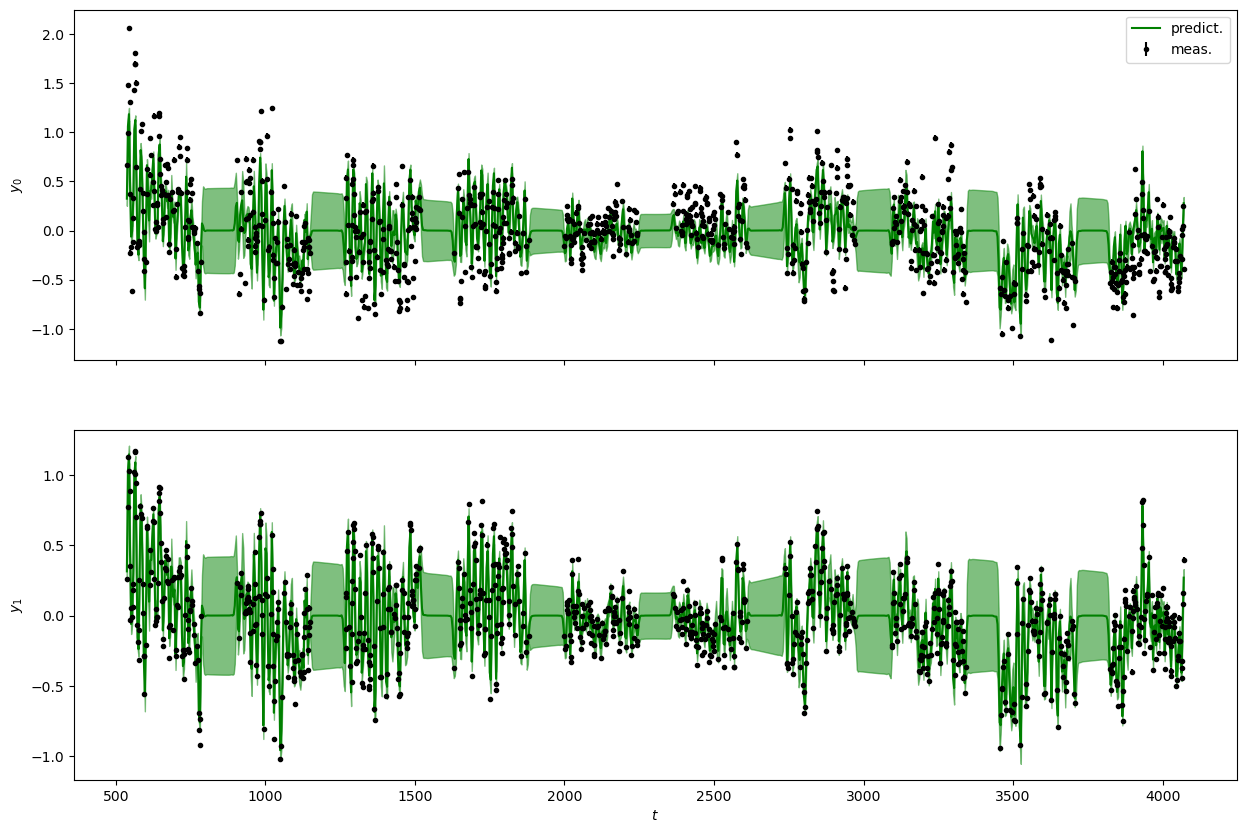

In [23]:
C.set_param(map_sample[:len(params)], params)
C.set_param([0.0], ['gp.rot_beta_1'])
C.set_param([np.var(y_full)], ['gp.rot_sig'])


tsmooth = np.linspace(np.min(t_full), np.max(t_full), 1000)
_, axs = plt.subplots(2, 1, sharex=True, figsize=(15, 10))


for k in range(2):
  # Predict time series k
  C.kernel['gp'].set_conditional_coef(series_id=k)
  # C.kernel['rot'].set_conditional_coef(series_id=k)
  # use MAP sample for modulation and offsets
  fc = alpha(t_full, map_sample[2], map_sample[3], map_sample[4],map_sample[5])
  fc_unnorm = (fc - map_sample[5]) / ((1.0 - map_sample[5]) / 2.0) - 1
  y_model = y_full.copy()
  # map_sample tail: [..., gamma_0, gamma_1, delta_0, delta_1]
  y_model[series_index[0]] -= map_sample[-4]*fc_unnorm[series_index[0]] + map_sample[-2]
  y_model[series_index[1]] -= map_sample[-3]*fc_unnorm[series_index[1]] + map_sample[-1]
  mu, var = C.conditional(y_model, tsmooth, calc_cov='diag')
  mu_res, _ = C.conditional(y_model, T[k], calc_cov='diag')
  if k == 0:
    res_rv = Y[k] - mu_res
  else:
    res_rhk = Y[k] - mu_res
  # Plot
  
  ax = axs[k]
  if k ==0 :
    ax.errorbar(T[k], Y[k]-(map_sample[-4]*fc_unnorm[series_index[0]]+map_sample[-2]), Yerr[k], fmt='.', color='k', label='meas.')
  if k == 1:
    ax.errorbar(T[k], Y[k]-(map_sample[-3]*fc_unnorm[series_index[1]]+map_sample[-1]), Yerr[k], fmt='.', color='k', label='meas.')
  ax.fill_between(tsmooth,
    mu - np.sqrt(var),
    mu + np.sqrt(var),
    color='g',
    alpha=0.5)
  ax.plot(tsmooth, mu, 'g', label='predict.')
  ax.set_ylabel(f'$y_{k}$')
ax.set_xlabel('$t$')
axs[0].legend()

plt.show()

1.433277019380087 1.5123679809984847


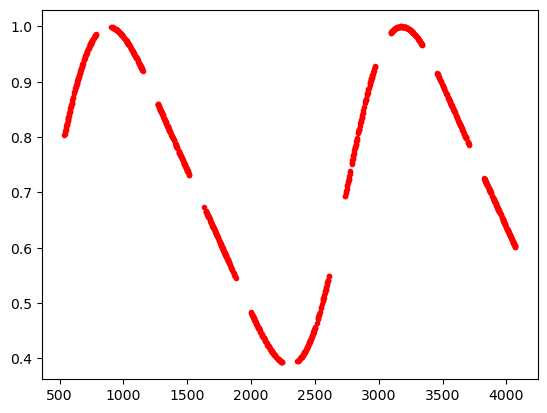

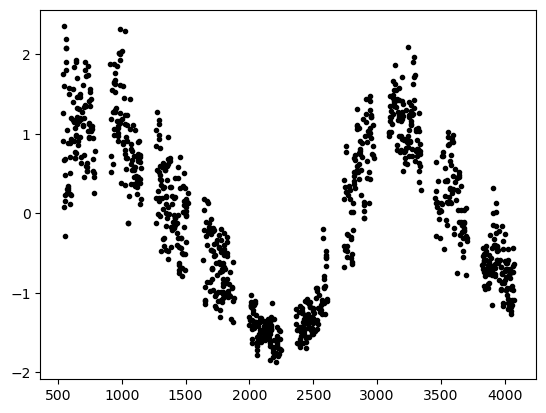

In [24]:
fc = alpha(t_full[series_index[0]], map_sample[2],map_sample[3],map_sample[4],map_sample[5])
plt.figure()
plt.plot(t_full[series_index[0]],fc, ".", color="red", label="fitted modulation function")
plt.figure()
plt.plot(t_full[series_index[0]],y_full[series_index[0]],".",color="black")
print(map_sample[-4],map_sample[-3])

RV only

In [78]:
stds = [np.std(y) for y in Y]
sig = np.var(y_full)   
prot = 20.0
Q = 1.0

rvjit = 0.1*stds[0]

# a1, a2, c, pcyc = 0.5, -6.1, 2.0, 2500.0

pcyc, phi, k, c = 2500.0, np.pi/10, 0.2, 0.01


C = cov.Cov(
  tt,
  err=term.Error(erv_norm),  
  rv_jit=term.Jitter(rvjit),
  gp=term.SimpleProductKernel(
      nonstat=NonStationaryKernel(alpha, alpha_grad, pcyc=pcyc, phi = phi, k = k, c = c),
      rot = term.SHOKernel(sig,prot, Q)
  )
)

rvjit_max = 5*stds[0]

prot_min = 18.0
prot_max = 22.0
Q_min = 0.8
Q_max = 1.7

pcyc_min = 2000.0
pcyc_max = 3000.0

alpha_0_max = 5*stds[0]
gamma_0_max = 5*stds[0]
bounds_list = [
    (0.1, rvjit_max),                     # rv_jit.sig
    (pcyc_min, pcyc_max),  
    (0,np.pi*2), # phi
    (-0.4,0.4),
    (0.1,0.9),
    (-alpha_0_max, alpha_0_max), 
    # (-10,10),
    
    (prot_min, prot_max),                 # rot.P0 (period)
    (Q_min, Q_max),                      # rot.Q (quality factor)
    # (0, alpha_0_max),         # rot.alpha_0 (set lower bound to zero)
    (0.6, gamma_0_max*2+2),         # rot.gamma_0
    (-gamma_0_max, gamma_0_max),         # delta_0 (offset for series 0)
]

C.param



['rv_jit.sig',
 'gp.nonstat_pcyc',
 'gp.nonstat_phi',
 'gp.nonstat_k',
 'gp.nonstat_c',
 'gp.rot_sig',
 'gp.rot_P0',
 'gp.rot_Q']

In [79]:
fitted = [k for k, key in enumerate(C.param)]  
params = [C.param[k] for k in fitted]
x0 = C.get_param(params)

x0 = np.append(x0,[0.0,0.0])

def negloglike(x, y, C):
  
  C.set_param(x[:len(params)], params)
  fc = alpha(tt, x[1],x[2],x[3],x[4])
  fc_unnorm = (fc - x[4]) / ((1.0 - x[4]) / 2.0) - 1
  y_model = y.copy()
  y_model -= (x[-2]*fc_unnorm + x[-1])

  nll = -C.loglike(y_model)
  # gradient
  lg = C.loglike_grad()
  dL_dy = np.asarray(lg[0]).reshape(-1)      # shape (N_total,) 
  dL_dparams = np.asarray(lg[1]).reshape(-1) # shape (12,)      

  base_grad = - dL_dparams[fitted]  

  # gradients wrt gamma (scale of fc)
  grad_gamma_0 = np.sum(dL_dy * fc_unnorm)

  # gradients wrt delta (additive offsets)
  grad_delta_0 = np.sum(dL_dy)

  nll_grad = np.concatenate([np.asarray(base_grad).ravel(), np.array([grad_gamma_0, grad_delta_0])])


  # nll_grad = -C.loglike_grad()[1][fitted]

  return (nll, nll_grad)


result = fmin_l_bfgs_b(negloglike, x0, args=(rv_norm, C), bounds=bounds_list)
xbest = result[0]

C.set_param(xbest[:len(params)], params)


print(params)
print(xbest)

['rv_jit.sig', 'gp.nonstat_pcyc', 'gp.nonstat_phi', 'gp.nonstat_k', 'gp.nonstat_c', 'gp.rot_sig', 'gp.rot_P0', 'gp.rot_Q']
[ 1.00000000e-01  2.49997842e+03  4.91797124e-01  2.27333426e-01
  4.30989354e-01  1.09829506e+00  2.00502293e+01  8.00000000e-01
  7.48867051e-01 -3.21900980e-02]


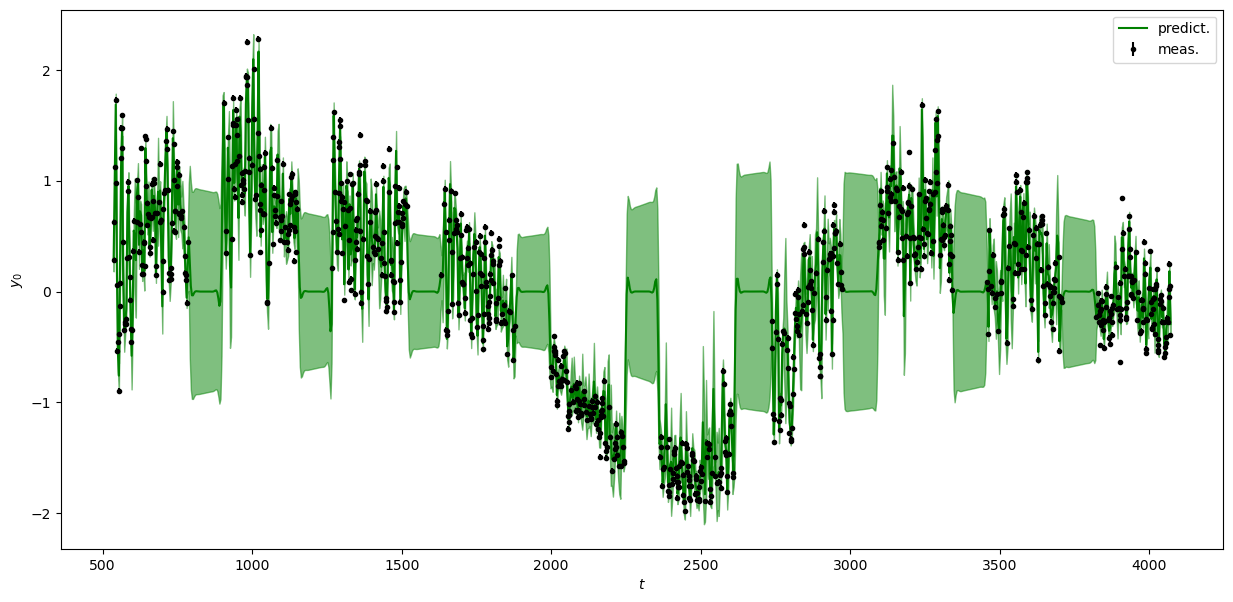

In [80]:
tsmooth = np.linspace(np.min(t_full), np.max(t_full), 1000)
_, axs = plt.subplots(1, 1, sharex=True, figsize=(15, 7))

fc = alpha(tt, xbest[1],xbest[2],xbest[3],xbest[4])
fc_unnorm = (fc - xbest[4]) / ((1.0 - xbest[4]) / 2.0) - 1
y_model = rv_norm.copy()
y_model -= (xbest[-2]*fc_unnorm + xbest[-1])

mu, var = C.conditional(y_model, tsmooth, calc_cov='diag')
mu_res, _ = C.conditional(y_model, tt, calc_cov='diag')

res_rv = rv_norm - mu_res


axs.errorbar(tt, rv_norm-(xbest[-2]*fc_unnorm+xbest[-1]), erv_norm, fmt='.', color='k', label='meas.')

axs.fill_between(tsmooth,
    mu - np.sqrt(var),
    mu + np.sqrt(var),
    color='g',
    alpha=0.5)
axs.plot(tsmooth, mu, 'g', label='predict.')
axs.set_ylabel(f'$y_{0}$')
axs.set_xlabel('$t$')
axs.legend()

plt.show()

In [81]:
def log_prior(theta):
    # unpack theta (added delta_0, delta_1 as final two entries)
    # rv_jit, rhk_jit, pcyc, phi, k_raw, c, rot_P0, rot_Q, rot_alpha_0, rot_alpha_1, rot_beta_0, gamma_0, gamma_1, delta_0, delta_1 = theta
    rv_jit, pcyc, phi, k, c, sig, rot_P0, rot_Q, gamma_0, delta_0= theta
    phi = phi % (2*np.pi)
    if 0.1 < rv_jit < rvjit_max and pcyc_min < pcyc < pcyc_max and 0 < phi < np.pi*2 and -0.4< k < 0.4 and 0.1 < c < 0.9 and -alpha_0_max < sig < alpha_0_max and prot_min < rot_P0 < prot_max and Q_min < rot_Q < Q_max and 0.0 < gamma_0 < gamma_0_max and -gamma_0_max < delta_0 < gamma_0_max:
        return 0.0
    return -np.inf

def log_probability(theta, y, C):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + -1*negloglike(theta, y, C)[0]

x0 = xbest.copy()
print(x0)
print(log_prior(x0))    

# x0 = [0.03, 0.2, 1500.0, 0.015, 4.0, 4.0, 4.0]
ndim = len(x0)
pos = x0 + 1e-4 * np.random.randn(ndim*3, ndim)
nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(rv_norm, C)
)
sampler.run_mcmc(pos, 4000, progress=True);



[ 1.00000000e-01  2.49997842e+03  4.91797124e-01  2.27333426e-01
  4.30989354e-01  1.09829506e+00  2.00502293e+01  8.00000000e-01
  7.48867051e-01 -3.21900980e-02]
-inf


100%|██████████| 4000/4000 [00:45<00:00, 87.02it/s]


['rv_jit.sig', 'gp.nonstat_pcyc', 'gp.nonstat_phi', 'gp.nonstat_k', 'gp.nonstat_c', 'gp.rot_sig', 'gp.rot_P0', 'gp.rot_Q', 'gamma_0', 'delta_0']


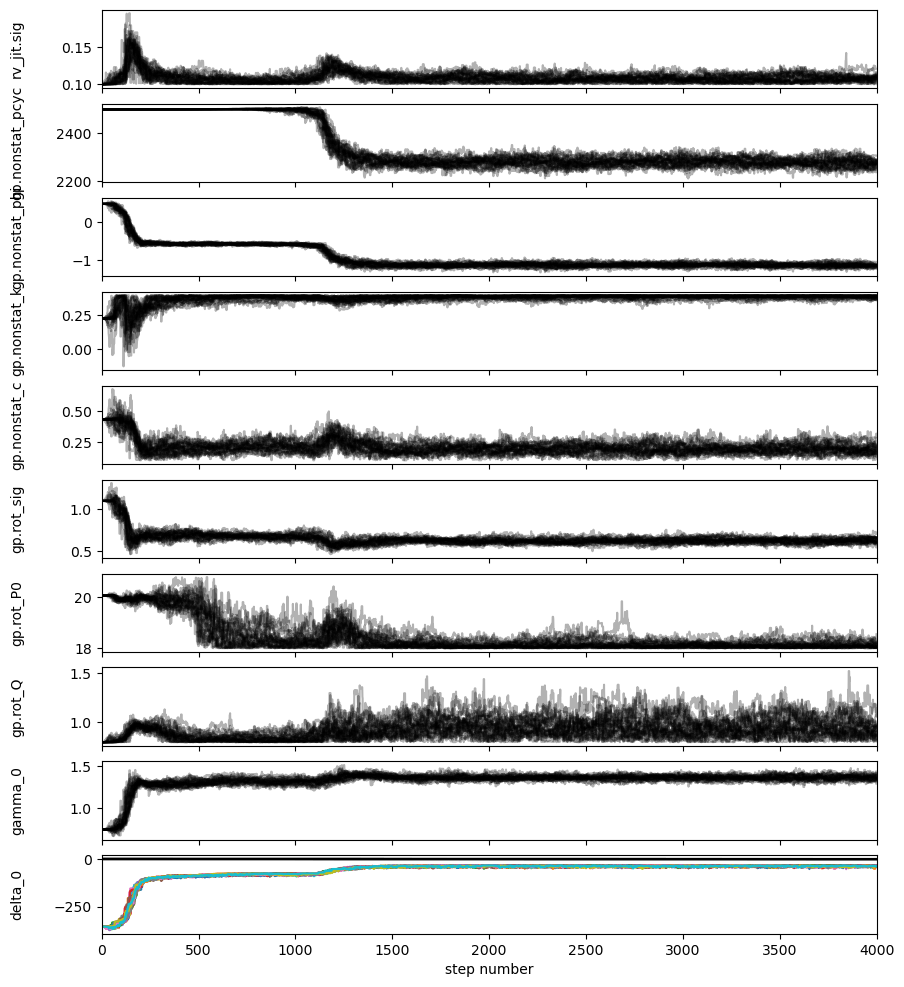

In [82]:
# ig, axes = plt.subplots(13, figsize=(10, 12), sharex=True)
ig, axes = plt.subplots(len(params) + 2, figsize=(10, 12), sharex=True)
samples = sampler.get_chain()

# labels = params + ['gamma_0', 'gamma_1', 'delta_0', 'delta_1']
labels = params + ['gamma_0', 'delta_0']
print(labels)
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

logp = sampler.get_log_prob(flat=False)
axes[-1].plot(logp)

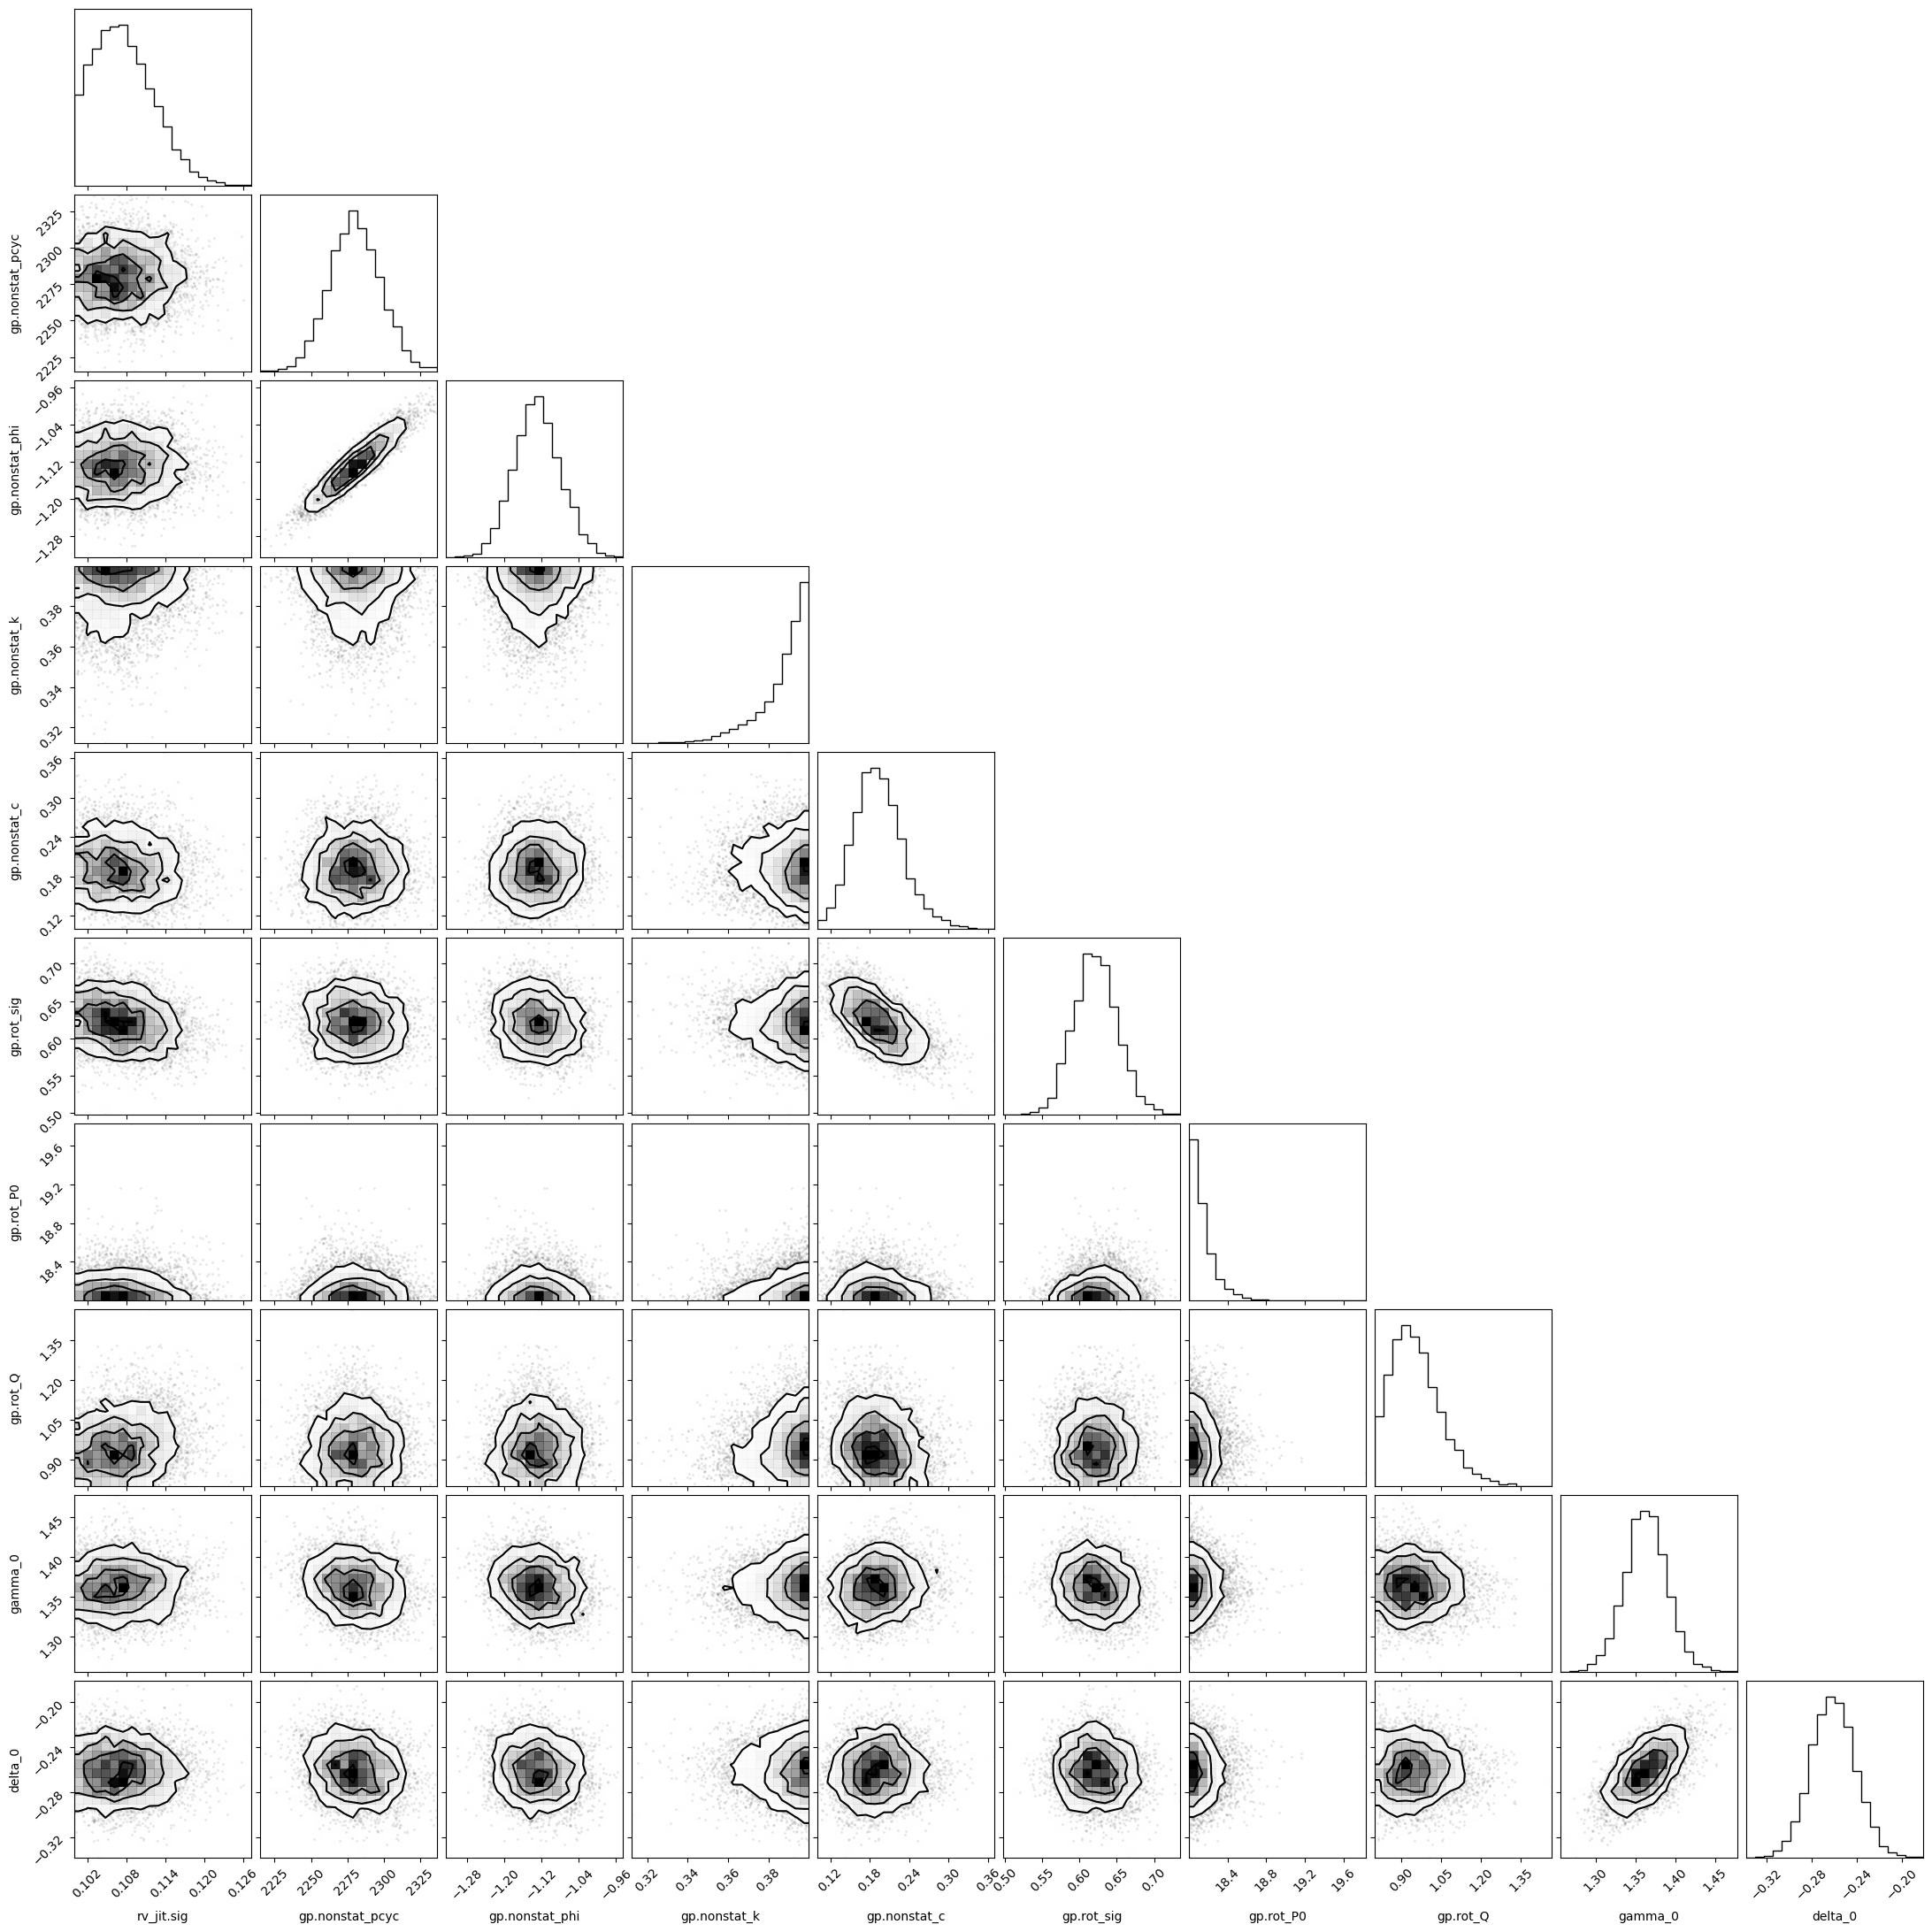

In [83]:
import corner

flat_samples = sampler.get_chain(discard=1500, thin=15, flat=True)

fig = corner.corner(
    flat_samples, labels=labels
);



In [71]:
burn = 1500   
thin = 1

flat_samples = sampler.get_chain(discard=burn, thin=thin, flat=True)   # shape (n_samples, ndim)
flat_logp    = sampler.get_log_prob(discard=burn, thin=thin, flat=True) # shape (n_samples,)

finite_mask = np.isfinite(flat_logp)
flat_samples = flat_samples[finite_mask]
flat_logp    = flat_logp[finite_mask]

map_idx = np.argmax(flat_logp)
map_sample = flat_samples[map_idx]
map_logp = flat_logp[map_idx]

print("MAP index (in flattened, post-burn chain):", map_idx)
print("MAP log-posterior:", map_logp)
print("MAP sample (theta):", map_sample)

MAP index (in flattened, post-burn chain): 33298
MAP log-posterior: -33.047511443559415
MAP sample (theta): [ 1.07454350e-01  2.26862739e+03 -1.16032777e+00  3.93772388e-01
  1.68770179e-01  6.37969374e-01  1.80025200e+01  9.72774379e-01
  1.36286831e+00 -2.67517519e-01]


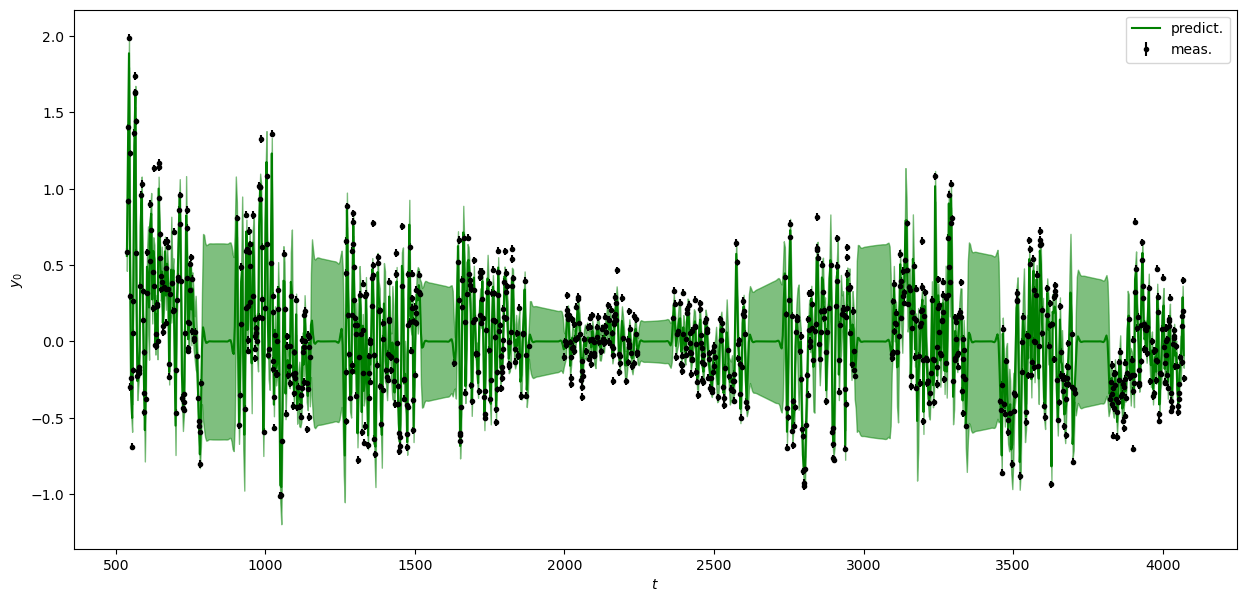

In [72]:
tsmooth = np.linspace(np.min(t_full), np.max(t_full), 1000)
_, axs = plt.subplots(1, 1, sharex=True, figsize=(15, 7))

fc = alpha(tt, map_sample[1],map_sample[2],map_sample[3],map_sample[4])
fc_unnorm = (fc - map_sample[4]) / ((1.0 - map_sample[4]) / 2.0) - 1
y_model = rv_norm.copy()
y_model -= (map_sample[-2]*fc_unnorm + map_sample[-1])

mu, var = C.conditional(y_model, tsmooth, calc_cov='diag')
mu_res, _ = C.conditional(y_model, tt, calc_cov='diag')

res_rv = rv_norm - mu_res


axs.errorbar(tt, rv_norm-(map_sample[-2]*fc_unnorm+map_sample[-1]), erv_norm, fmt='.', color='k', label='meas.')

axs.fill_between(tsmooth,
    mu - np.sqrt(var),
    mu + np.sqrt(var),
    color='g',
    alpha=0.5)
axs.plot(tsmooth, mu, 'g', label='predict.')
axs.set_ylabel(f'$y_{0}$')
axs.set_xlabel('$t$')
axs.legend()

plt.show()